# ESS Battery Cycle Life — EDA

Batch 간 수명 분포, 초기 열화, ΔQ(V), 충전 정책과 상관 구조를 실제 실행 결과로 확인한다.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
RESULTS = ROOT / 'results'


## 1. Data Load / Structure

In [2]:
summary = pd.read_csv(RESULTS/'tables/cycle_life_summary.csv')
summary

,batch,count,mean,median,std,min,max,short_pct,middle_pct,long_pct
0,Batch1,41,838.585366,842.0,194.892788,534.0,1227.0,0.000000,75.609756,24.390244
1,Batch2,34,550.705882,468.5,221.641196,392.0,1186.0,76.470588,14.705882,8.823529
2,Batch3,40,1032.000000,964.5,308.598403,541.0,1935.0,0.000000,52.500000,47.500000


## 2. Q1 — Cycle Life Distribution

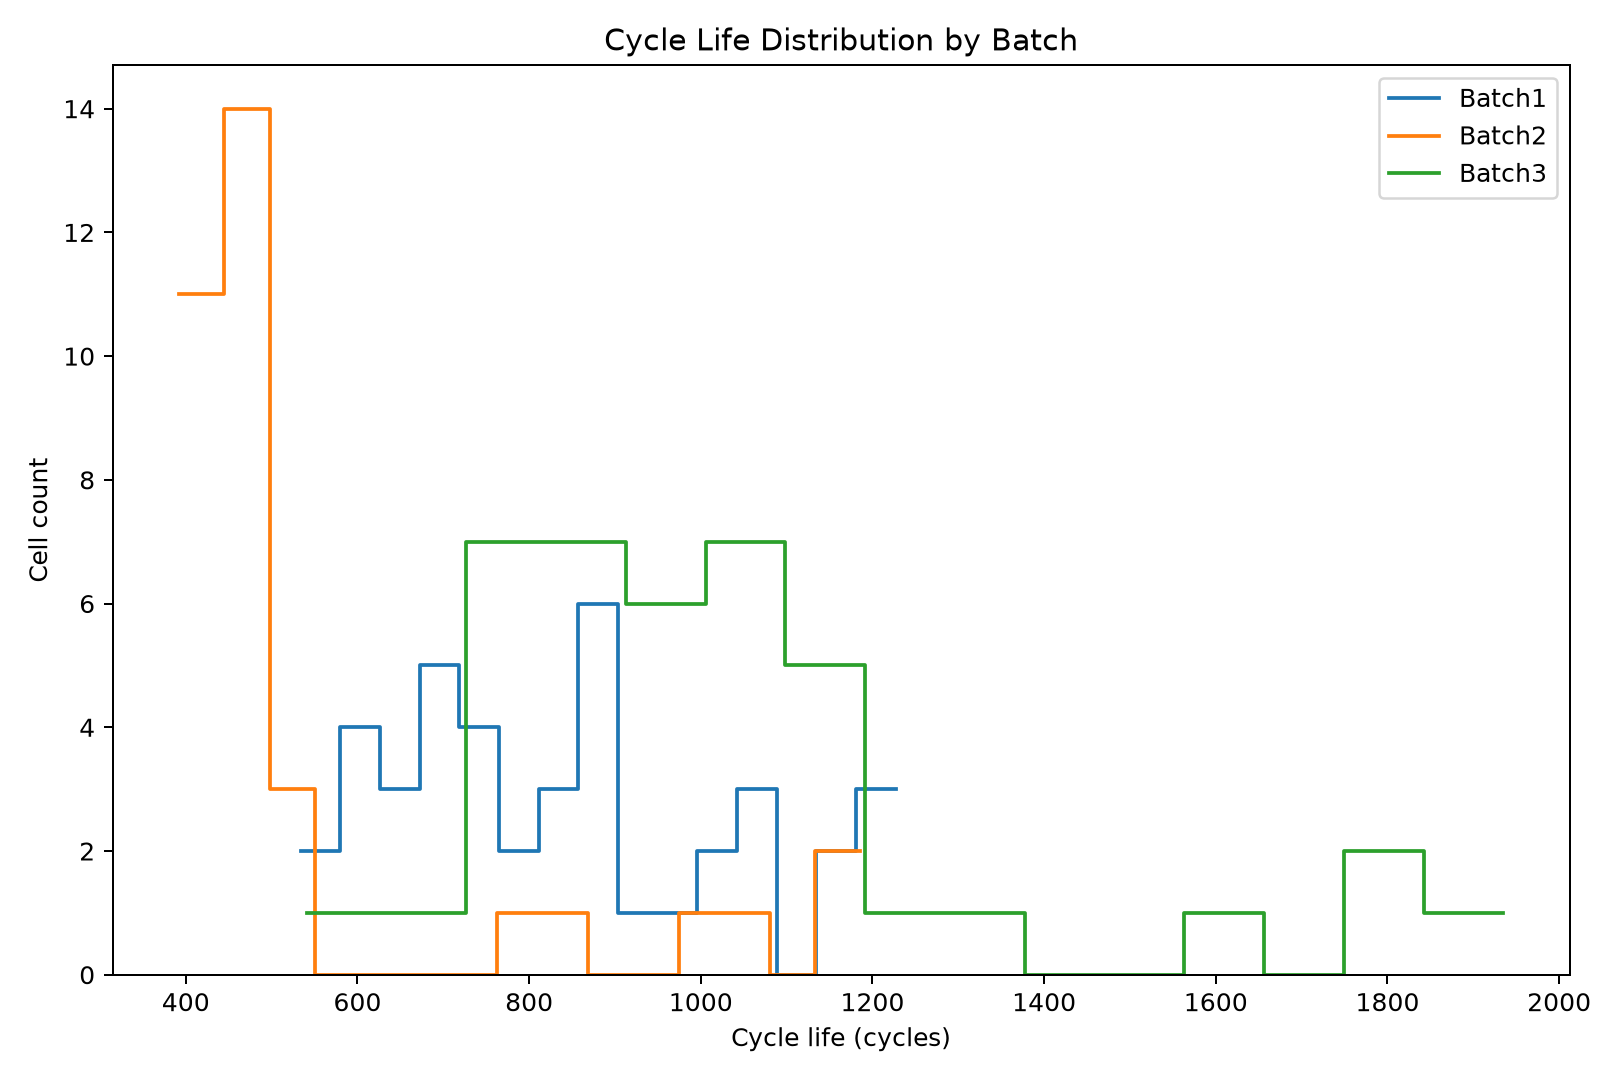

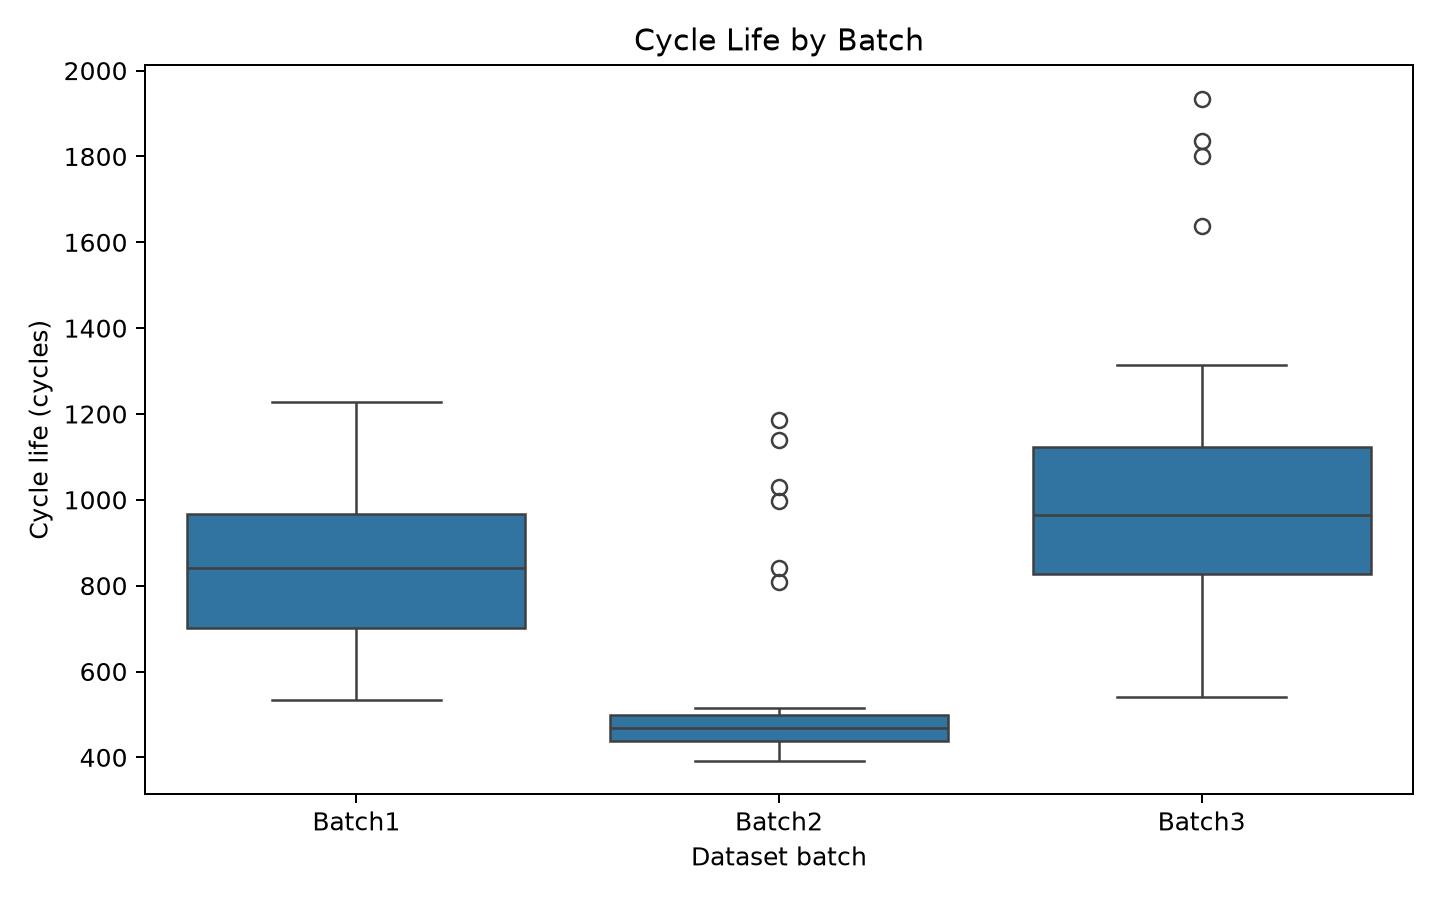

In [3]:
display(Image(filename=RESULTS/'figures/eda_cycle_life_hist.png')); display(Image(filename=RESULTS/'figures/eda_cycle_life_boxplot.png'))

Batch 2는 단수명 비중이 크고 Batch 3는 장수명 비중이 커서 Batch 1과 뚜렷한 분포 이동이 존재한다.

## 3. Q2 — Capacity Degradation

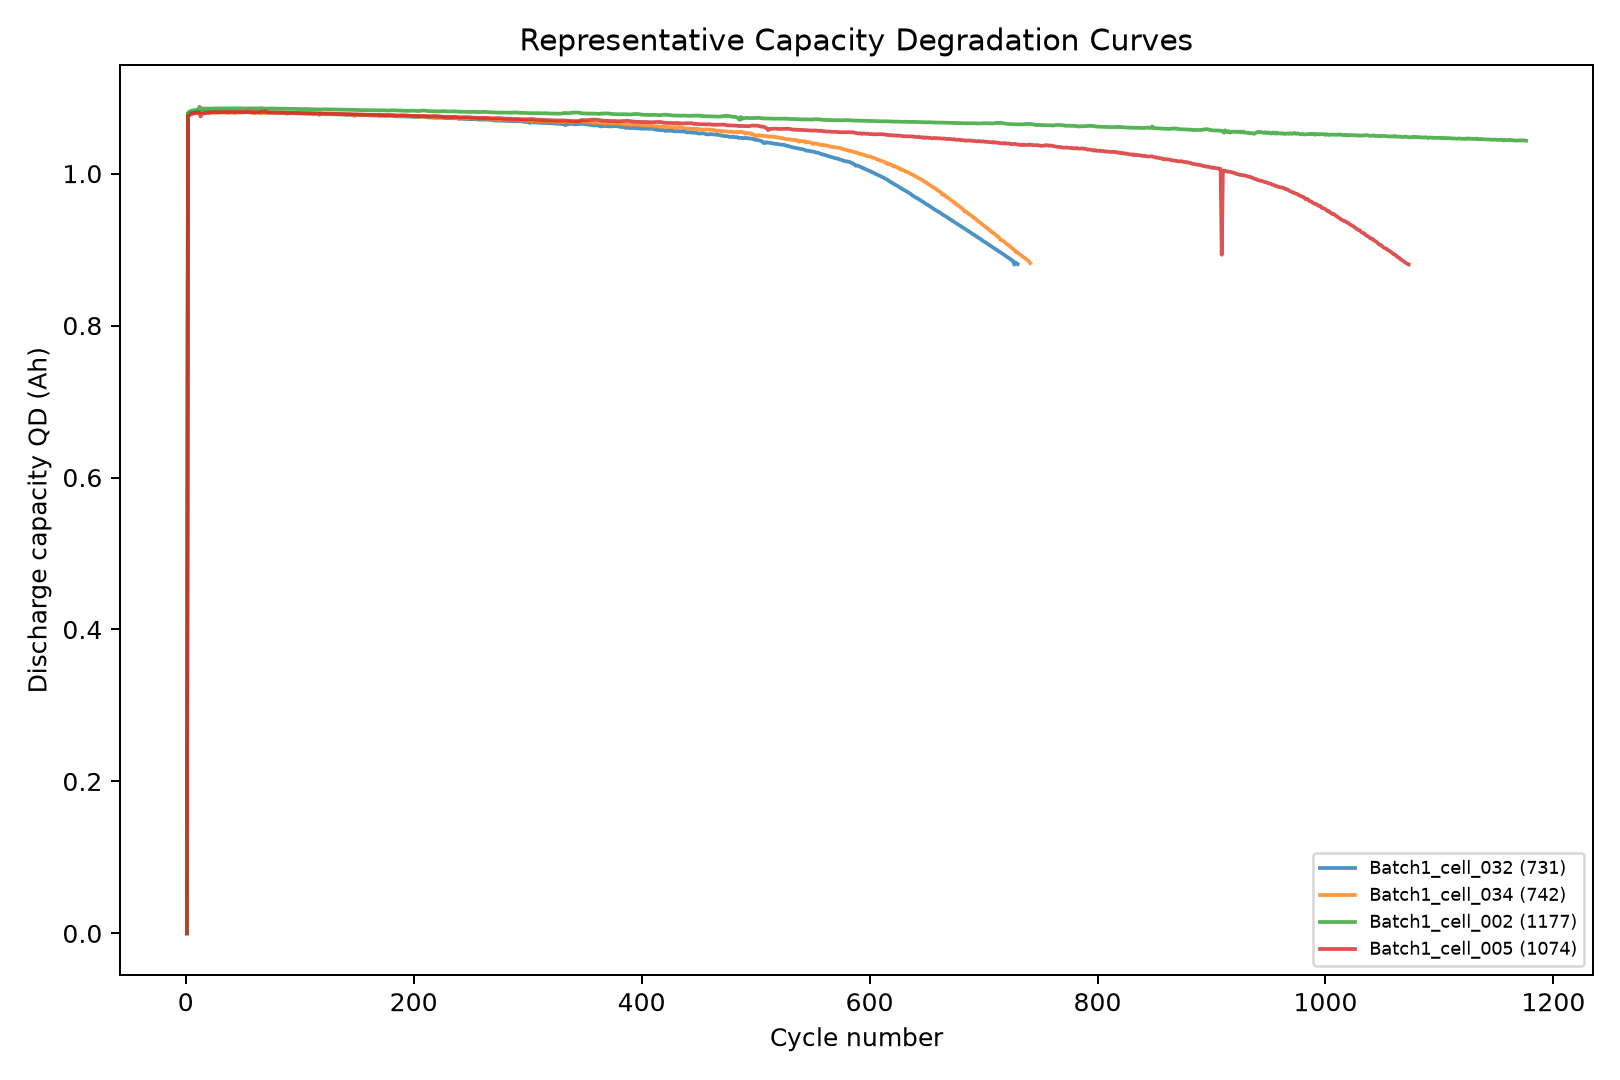

In [4]:
display(Image(filename=RESULTS/'figures/eda_degradation_curve.png'))

초기 QD 절대값만으로는 셀 수명을 충분히 구분하기 어려워 전압 축의 미세 변화인 ΔQ(V)를 사용한다.

## 4. Q3 — ΔQ(V)

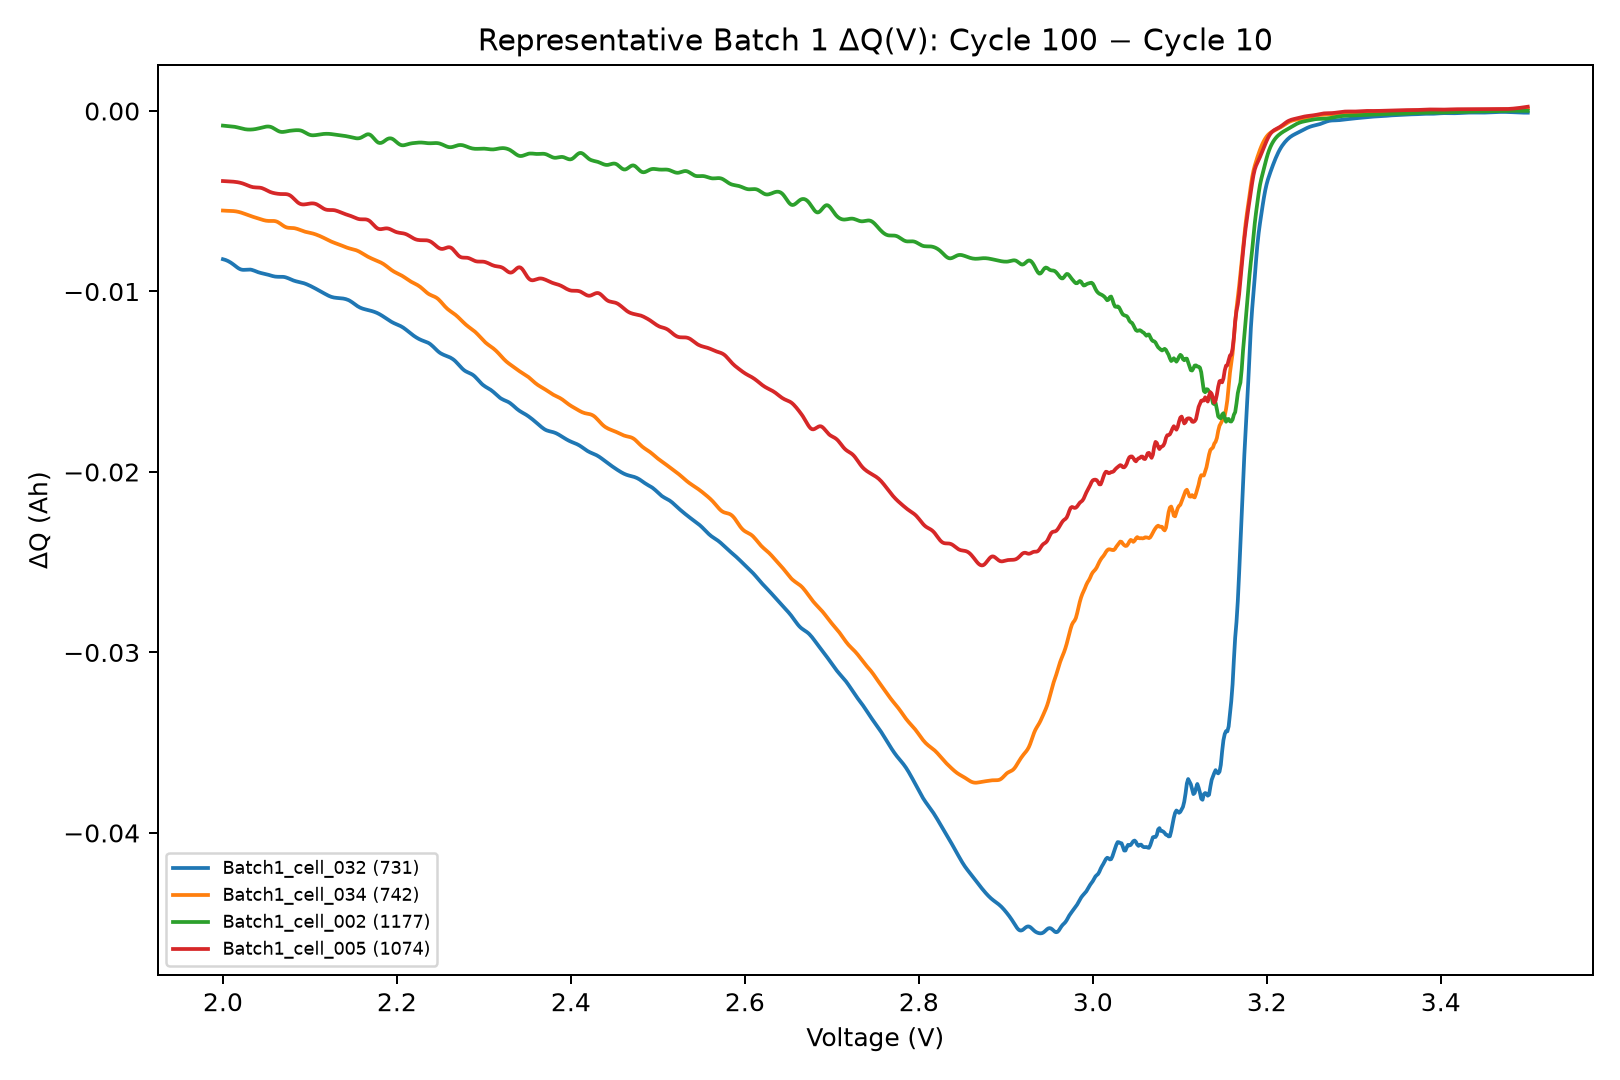

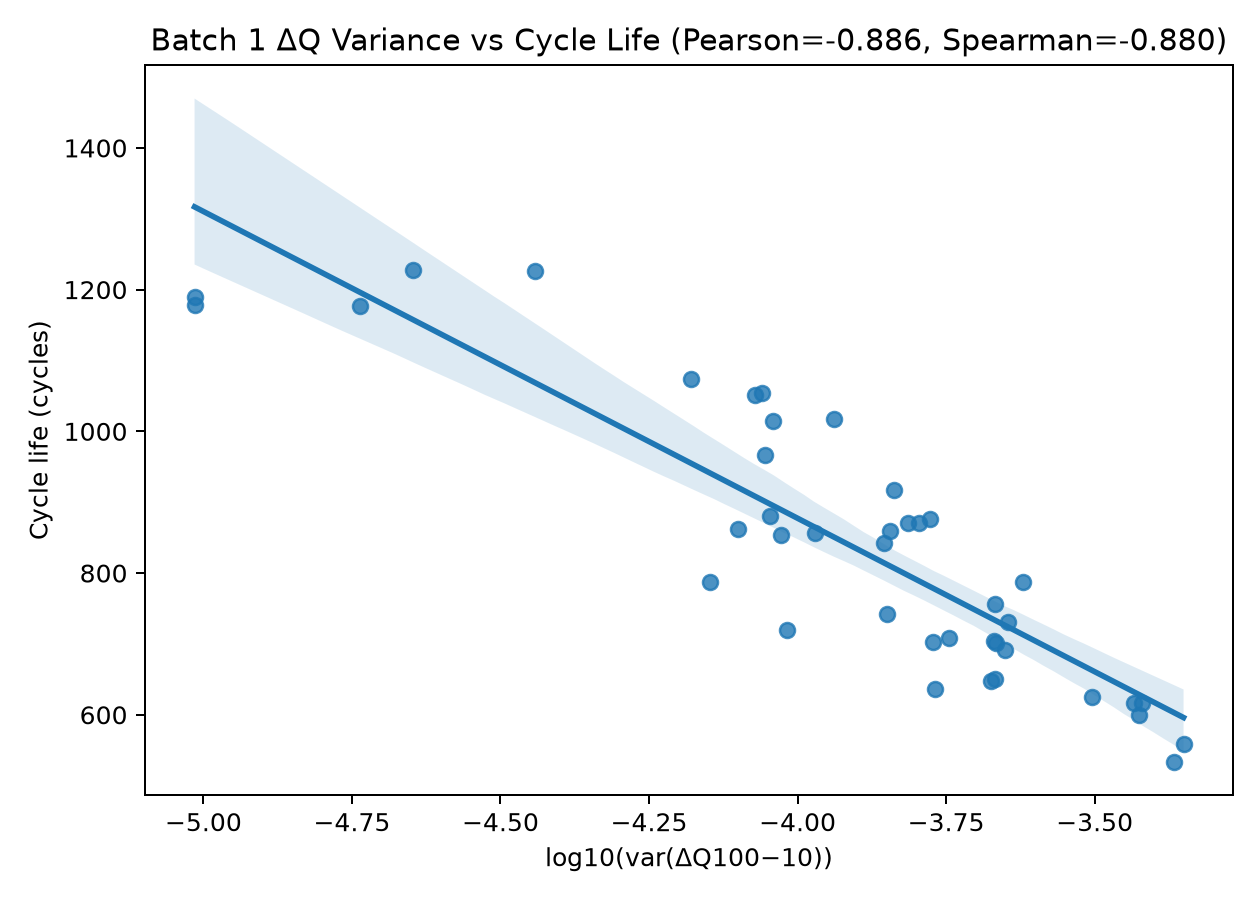

,feature,pearson,spearman
1,log_dq_var,-0.885847,-0.87978


In [5]:
display(Image(filename=RESULTS/'figures/eda_delta_q_curve.png')); display(Image(filename=RESULTS/'figures/eda_delta_q_vs_cycle_life.png'))
corr = pd.read_csv(RESULTS/'tables/feature_target_correlations.csv'); corr[corr.feature=='log_dq_var']

## 5. Q4 — Charging Policy

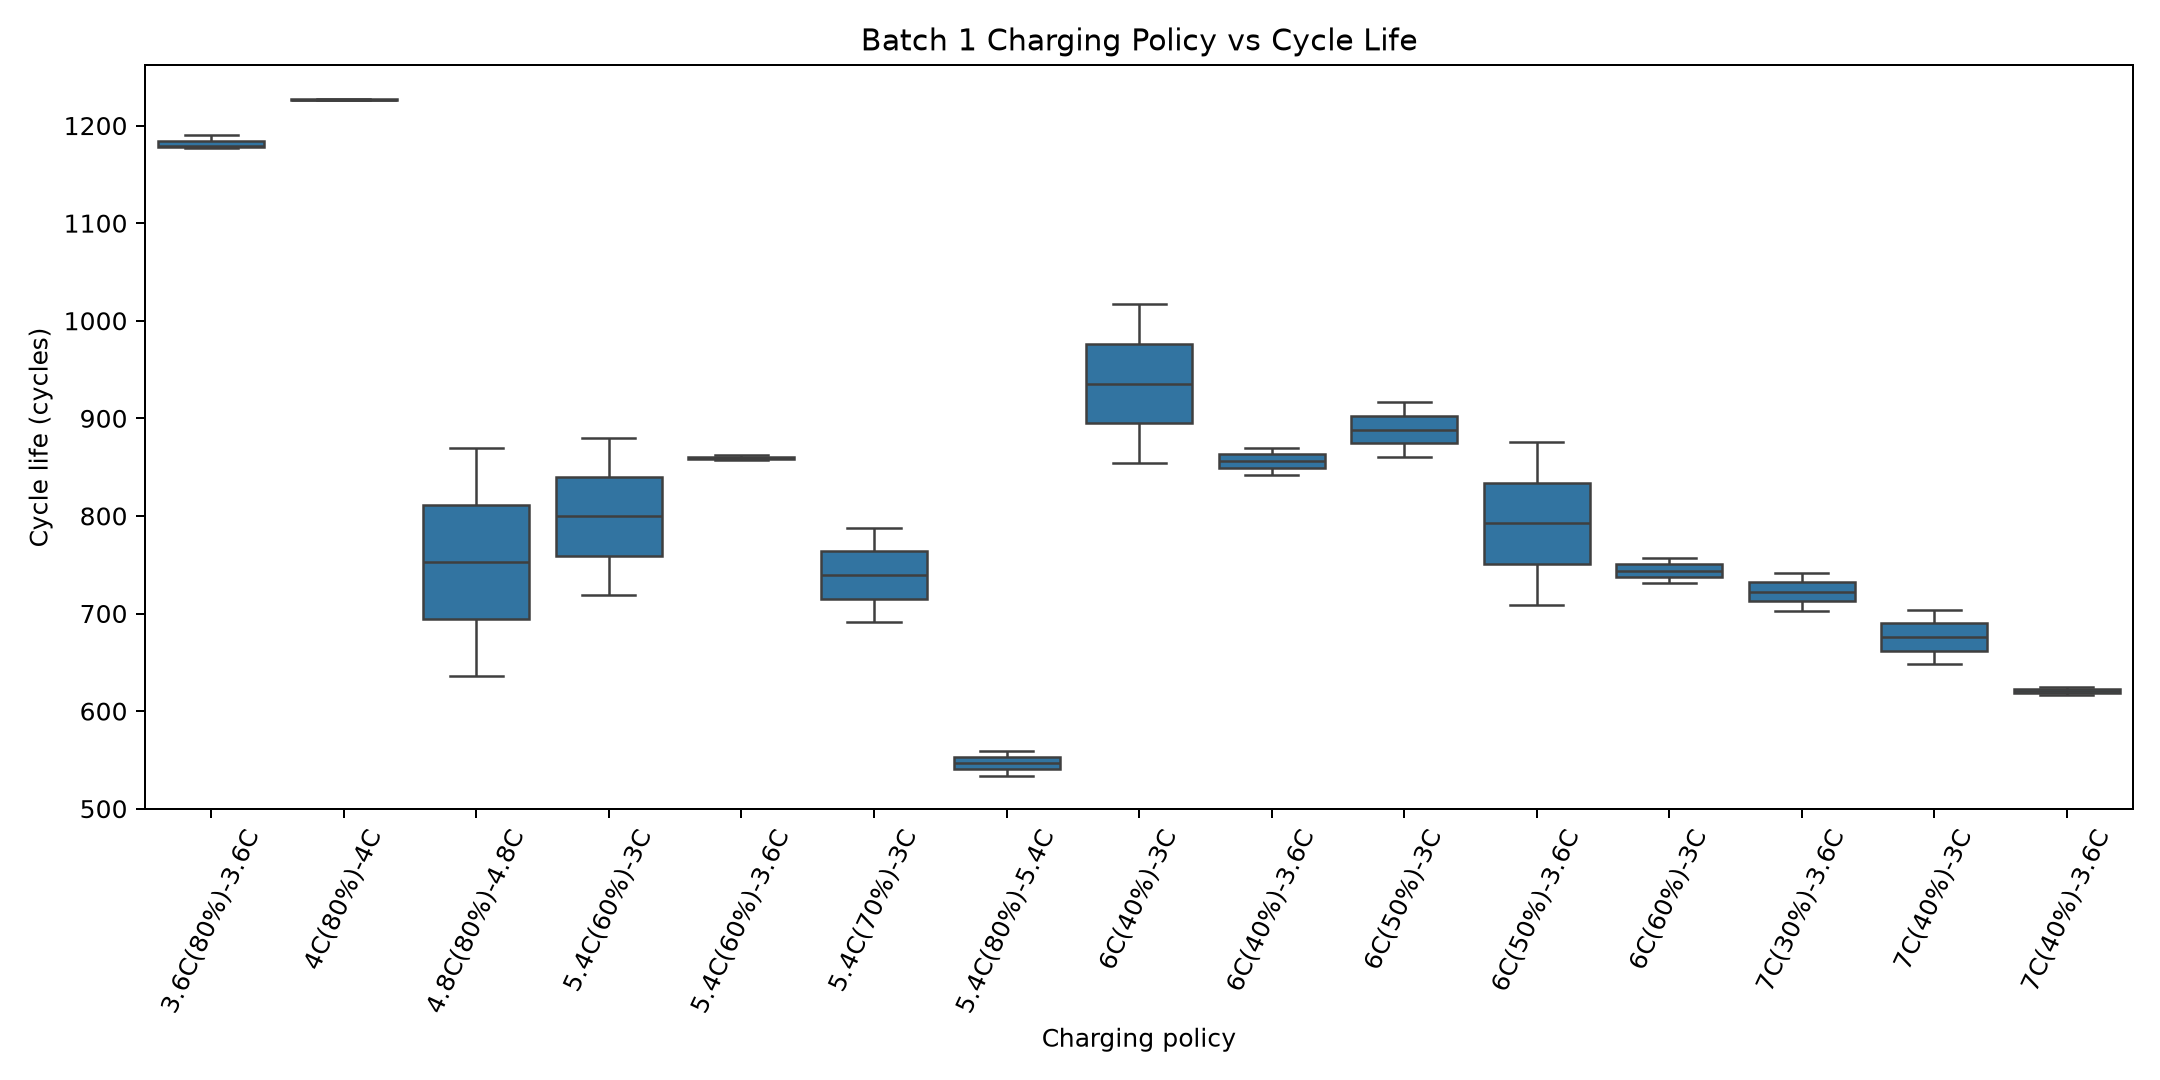

,charging_policy,count,mean,median,std
0,3.6C(80%)-3.6C,3,1182.0,1179.0,7.000000
1,4.4C(80%)-4.4C,1,1074.0,1074.0,NaN
2,4.8C(80%)-4.8C,2,753.0,753.0,165.462987
3,4C(80%)-4C,2,1226.5,1226.5,0.707107
4,5.4C(40%)-3.6C,1,1054.0,1054.0,NaN
5,5.4C(50%)-3C,1,788.0,788.0,NaN
6,5.4C(60%)-3.6C,2,859.5,859.5,3.535534
7,5.4C(60%)-3C,2,799.5,799.5,113.844192
8,5.4C(70%)-3C,2,739.5,739.5,68.589358
9,5.4C(80%)-5.4C,2,546.5,546.5,17.677670


In [6]:
display(Image(filename=RESULTS/'figures/eda_charging_policy.png')); pd.read_csv(RESULTS/'tables/charging_policy_summary.csv').head(10)

정책별 차이는 관찰적 연관이며 인과효과로 해석하지 않는다.

## 6. Q5 — Correlation / Conclusions

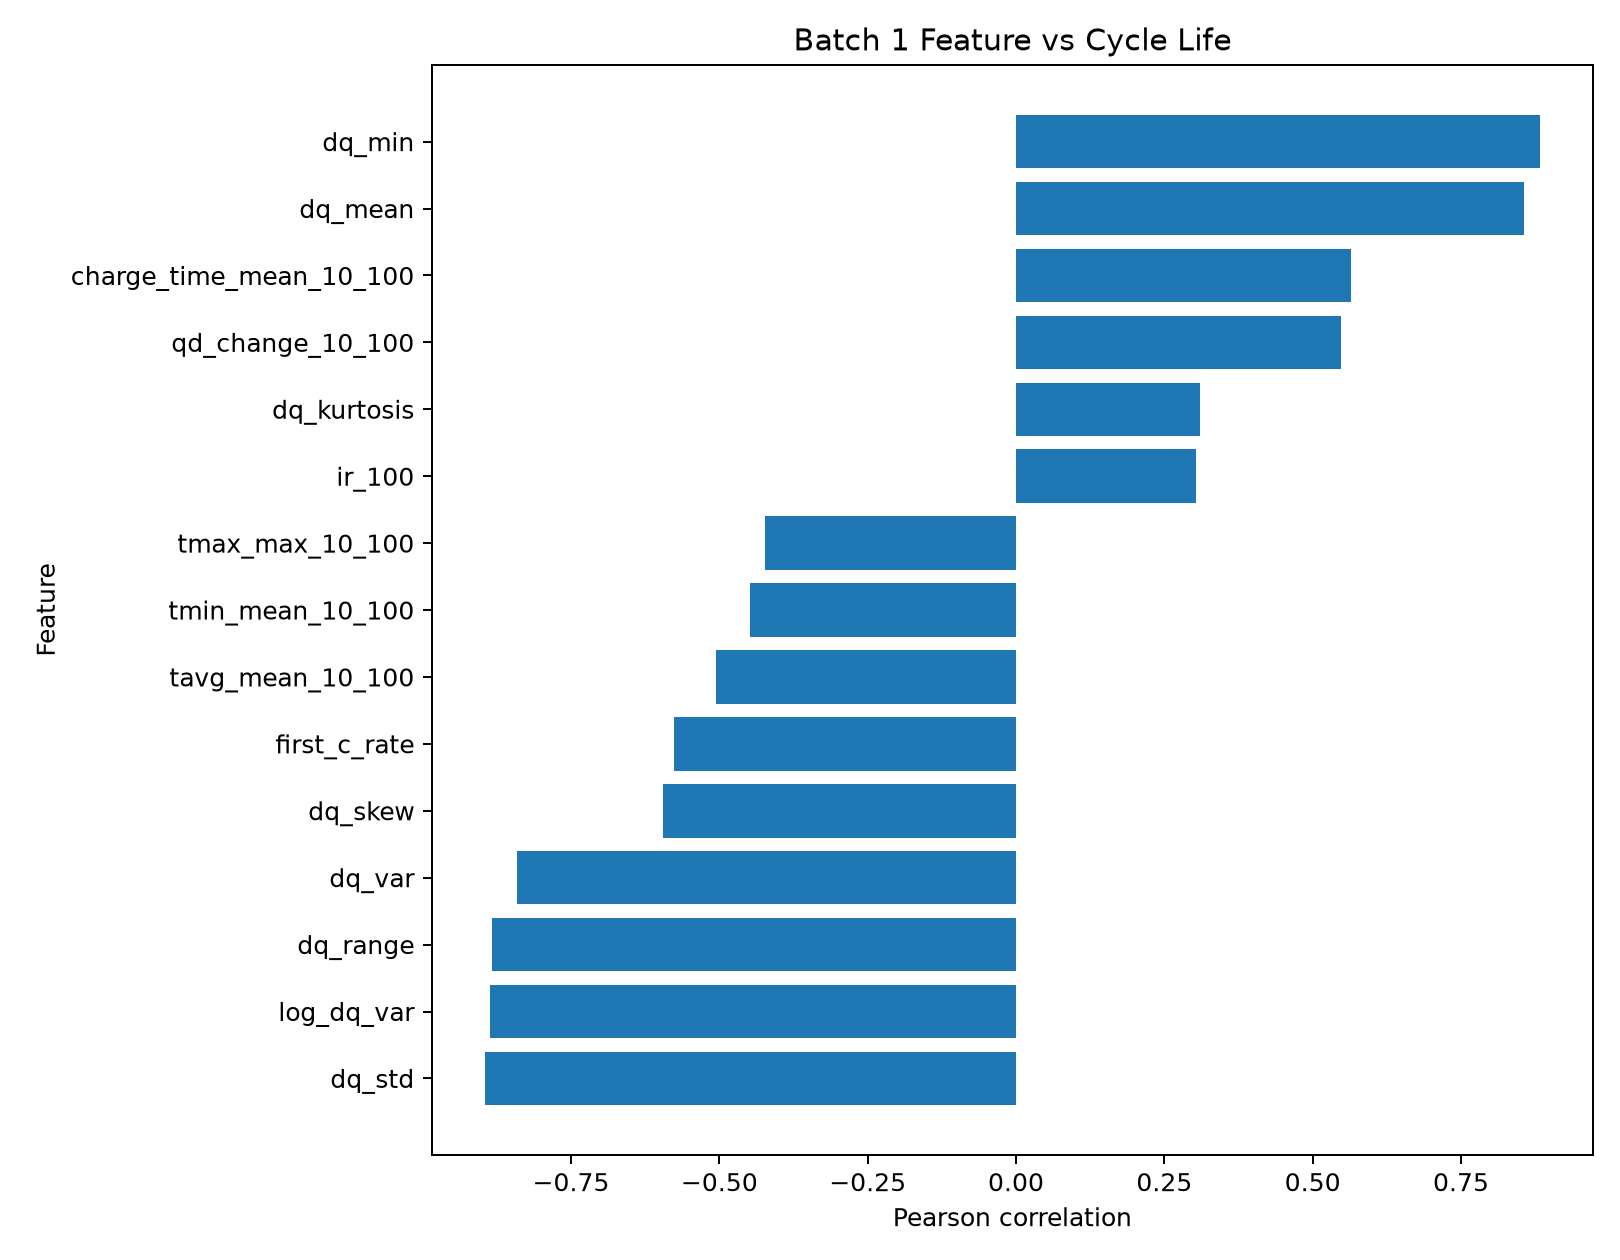

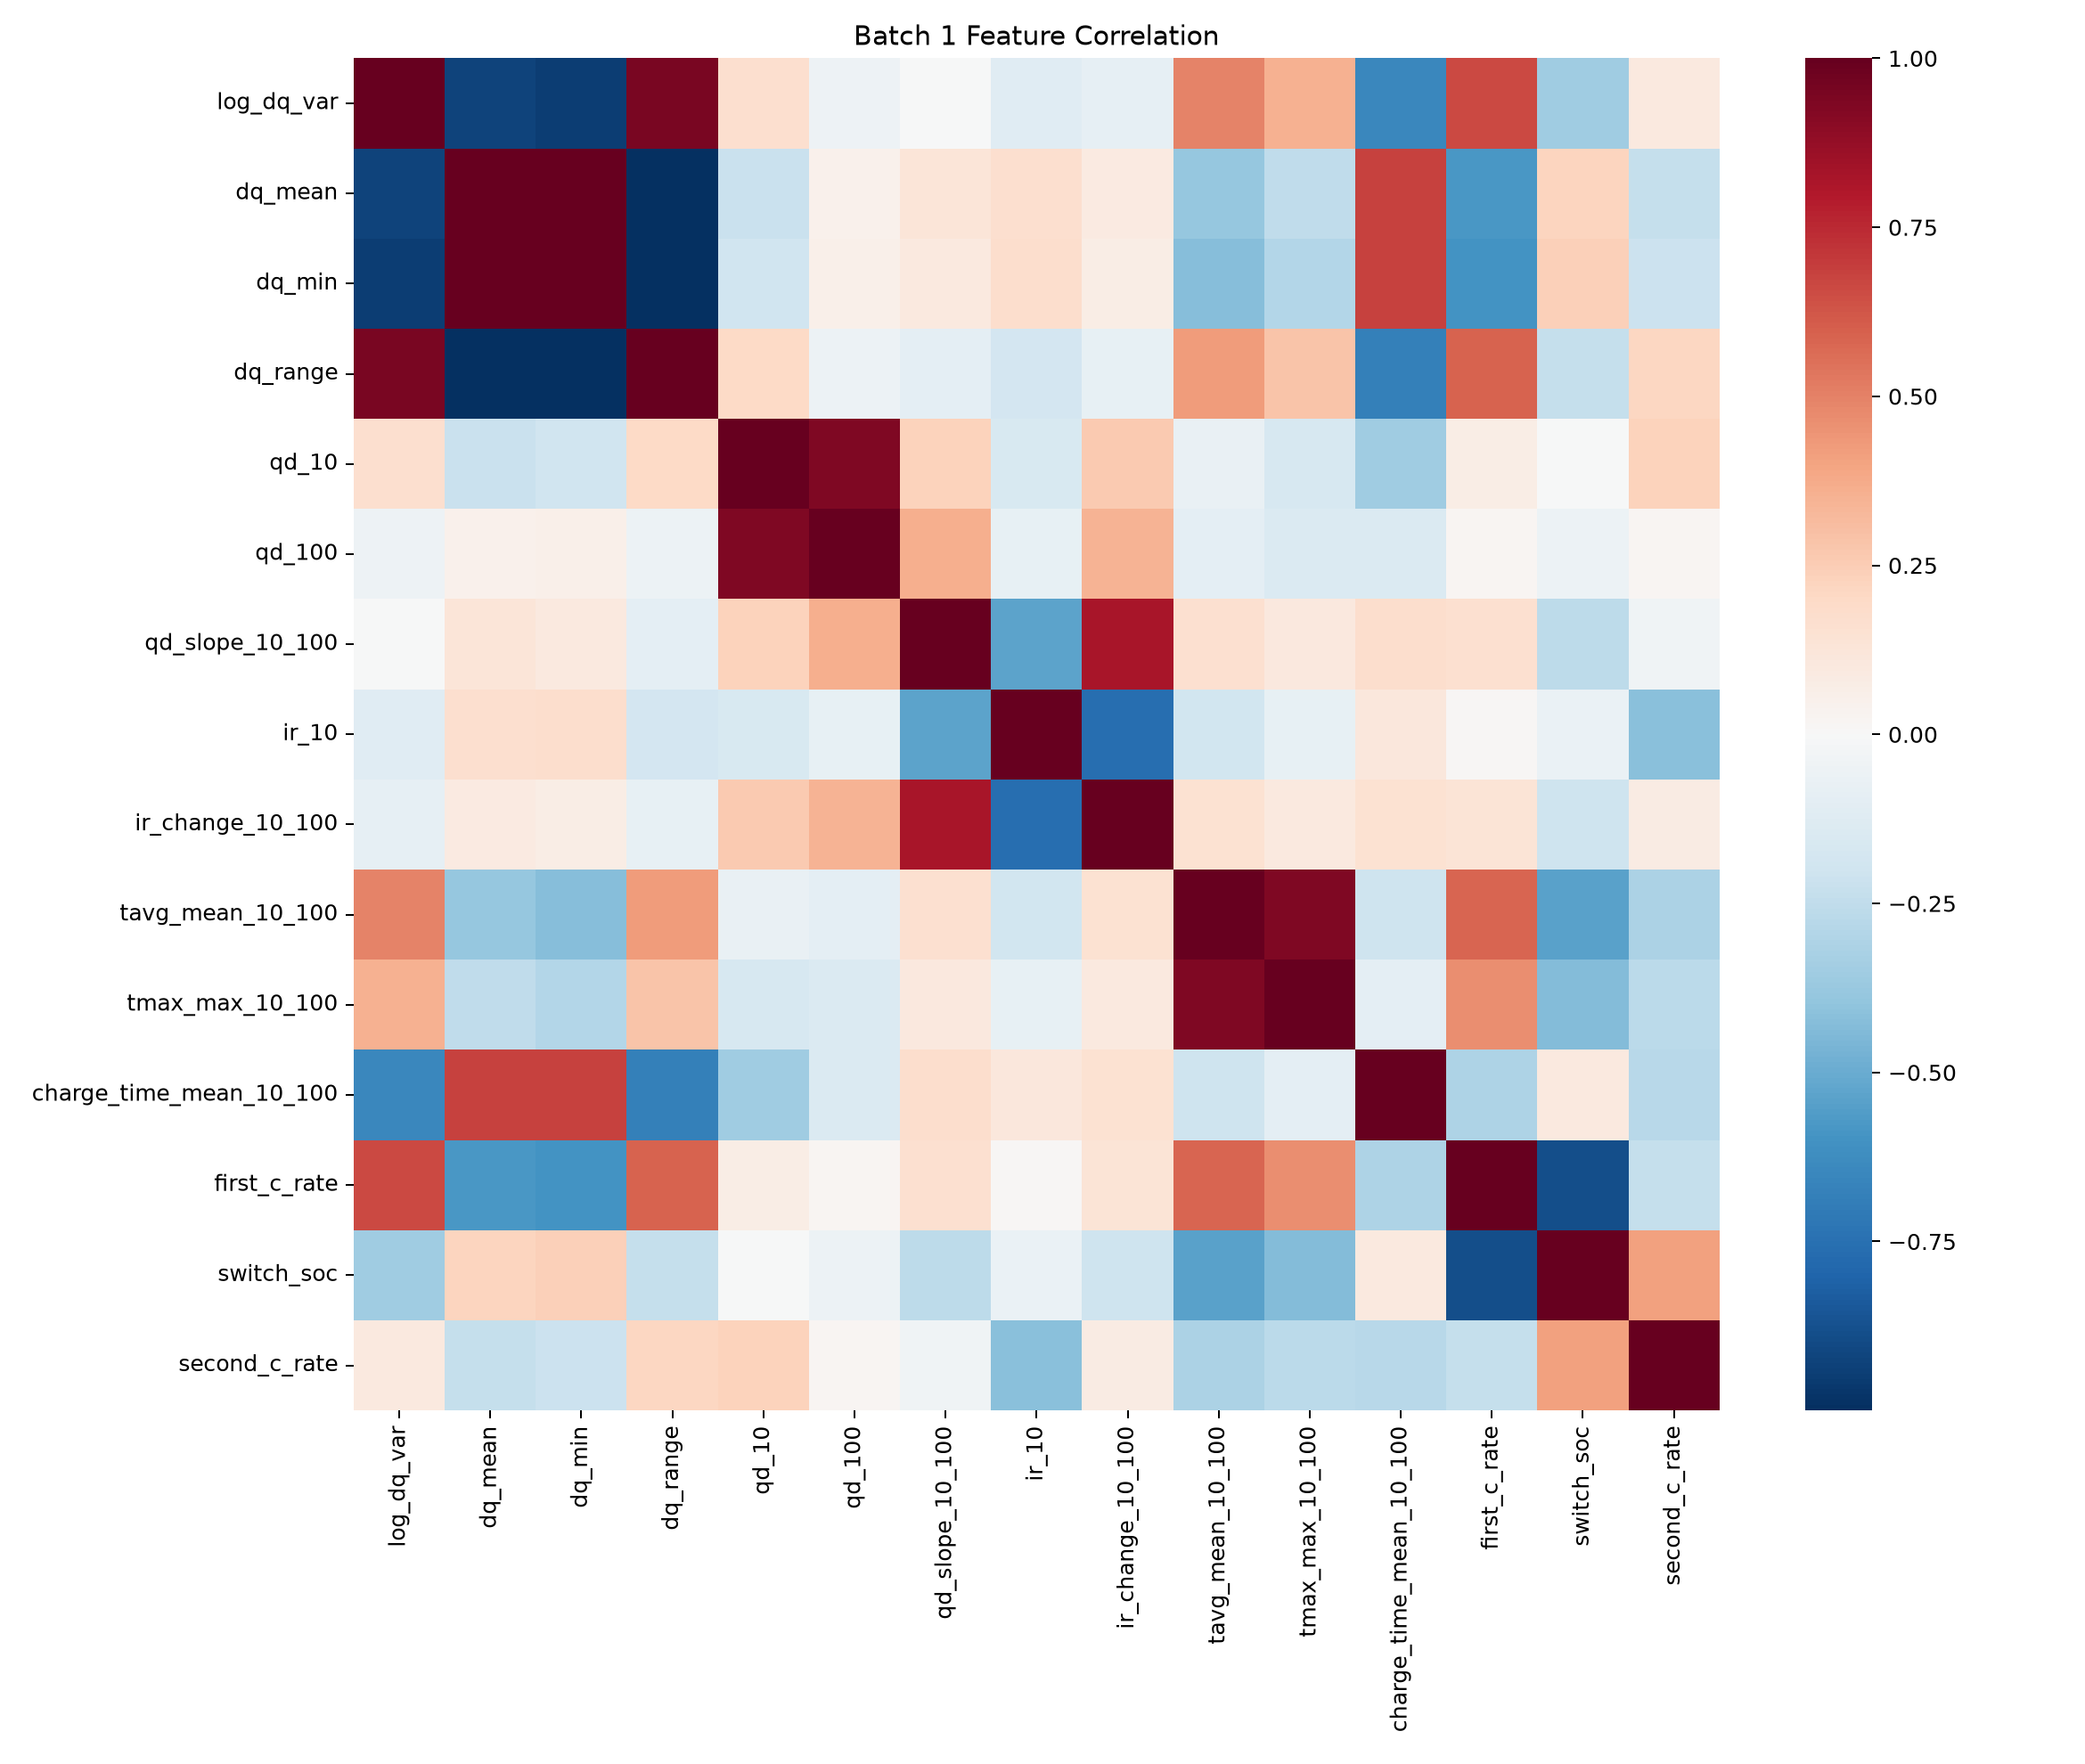

In [7]:
display(Image(filename=RESULTS/'figures/eda_feature_target_corr.png')); display(Image(filename=RESULTS/'figures/eda_feature_corr_heatmap.png'))

ΔQ 파생 변수끼리 다중공선성이 크므로 정규화 선형 모델을 주 후보로 비교하고, 외부 배치는 선택·튜닝에 사용하지 않는다.